In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv(
    "../output/full_dataset.csv",
    sep=";"
)

print(df.shape)

df.head()

(498, 22)


,word_count,sentence_count,flesch_reading_ease,gunning_fog,flesch_kincaid_grade,avg_sentence_length,avg_letter_per_word,lexicon_count,figure_count,table_count,...,doi,file,citation_count,publication_year,citations_per_year,journal_name,published_flag,is_open_access,type,openalex_id
0,8022,525,50.249703,12.883106,10.020928,15.177143,5.127385,7968,4,12,...,10.1101/2022.03.14.484320,10.1101_2022.03.14.484320.pdf,2,2022,0.4,bioRxiv (Cold Spring Harbor Laboratory),1,True,preprint,https://openalex.org/W4220704013
1,15734,940,40.428974,14.560889,11.690550,16.384043,5.439387,15401,58,8,...,10.1101/2022.05.01.490196,10.1101_2022.05.01.490196.pdf,13,2022,2.6,bioRxiv (Cold Spring Harbor Laboratory),1,True,preprint,https://openalex.org/W4225371151
2,5921,353,52.057010,12.566774,10.090090,16.470255,5.148435,5814,4,9,...,10.1101/2022.05.19.492257,10.1101_2022.05.19.492257.pdf,0,2022,NaN,bioRxiv (Cold Spring Harbor Laboratory),1,True,preprint,https://openalex.org/W4280534360
3,6799,392,42.181152,14.797494,11.612486,17.053571,5.400898,6685,9,4,...,10.1101/2022.06.06.495023,10.1101_2022.06.06.495023.pdf,2,2022,0.4,bioRxiv (Cold Spring Harbor Laboratory),1,True,preprint,https://openalex.org/W4281768141
4,12870,754,46.634595,13.867955,10.940780,16.850133,5.297521,12705,36,6,...,10.1101/2022.11.20.517270,10.1101_2022.11.20.517270.pdf,6,2022,1.2,bioRxiv (Cold Spring Harbor Laboratory),1,True,preprint,https://openalex.org/W4309653438


In [4]:
df.isnull().sum()

word_count                0
sentence_count            0
flesch_reading_ease       0
gunning_fog               0
flesch_kincaid_grade      0
avg_sentence_length       0
avg_letter_per_word       0
lexicon_count             0
figure_count              0
table_count               0
section_count             0
reference_count           0
doi                       0
file                      0
citation_count            0
publication_year          0
citations_per_year      272
journal_name              0
published_flag            0
is_open_access            0
type                      0
openalex_id               0
dtype: int64

In [5]:
df.describe()

,word_count,sentence_count,flesch_reading_ease,gunning_fog,flesch_kincaid_grade,avg_sentence_length,avg_letter_per_word,lexicon_count,figure_count,table_count,section_count,reference_count,citation_count,publication_year,citations_per_year,published_flag
count,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.0,498.0,498.000000,498.000000,226.000000,498.0
mean,11529.333333,693.556225,40.721874,14.645224,11.718301,16.660198,5.392448,11377.267068,26.377510,11.026104,0.0,0.0,1.130522,2024.686747,1.003230,1.0
std,3970.226179,260.310459,6.368260,1.179645,1.159072,2.118447,0.258387,3908.169844,30.252094,11.269219,0.0,0.0,2.198644,0.613616,1.024345,0.0
min,1819.000000,109.000000,1.511529,10.549458,7.881238,9.923827,4.383563,1809.000000,0.000000,0.000000,0.0,0.0,0.000000,2022.000000,0.250000,1.0
25%,8774.250000,516.250000,36.991590,13.813757,10.926901,15.200886,5.230088,8667.000000,7.000000,4.000000,0.0,0.0,0.000000,2025.000000,0.500000,1.0
50%,11250.500000,657.000000,40.909136,14.682593,11.665888,16.561070,5.389483,11087.500000,15.000000,8.000000,0.0,0.0,0.000000,2025.000000,0.670000,1.0
75%,13928.750000,830.750000,44.992182,15.379712,12.464343,18.096702,5.534040,13750.250000,38.000000,14.000000,0.0,0.0,1.000000,2025.000000,1.000000,1.0
max,27903.000000,2153.000000,58.248721,19.206678,16.315486,26.497647,7.722934,27656.000000,330.000000,90.000000,0.0,0.0,20.000000,2026.000000,10.000000,1.0


Gunning Fog vs Citations

Correlation: 0.04469635531672119


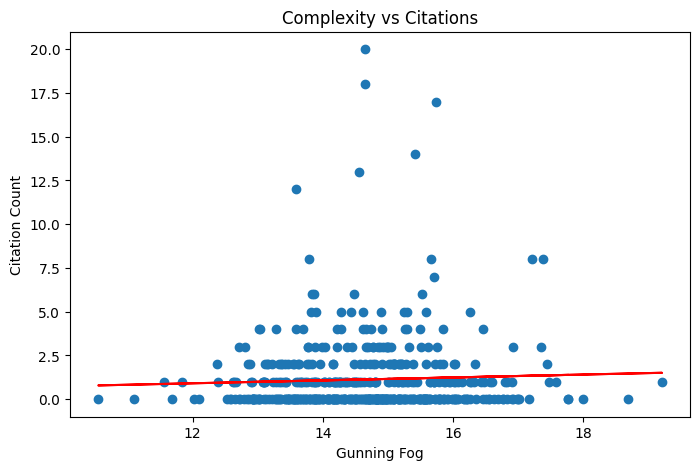

In [28]:
corr = df["gunning_fog"].corr(
    df["citation_count"]
)

print("Correlation:", corr)

plt.figure(figsize=(8,5))

plt.scatter(
    df["gunning_fog"],
    df["citation_count"]
)

# Regressionslinie
import numpy as np

x = df["gunning_fog"]
y = df["citation_count"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x), color="red")

plt.xlabel("Gunning Fog")
plt.ylabel("Citation Count")
plt.title("Complexity vs Citations")

plt.show()

Sentence Length

Correlation: 0.0752773594373564


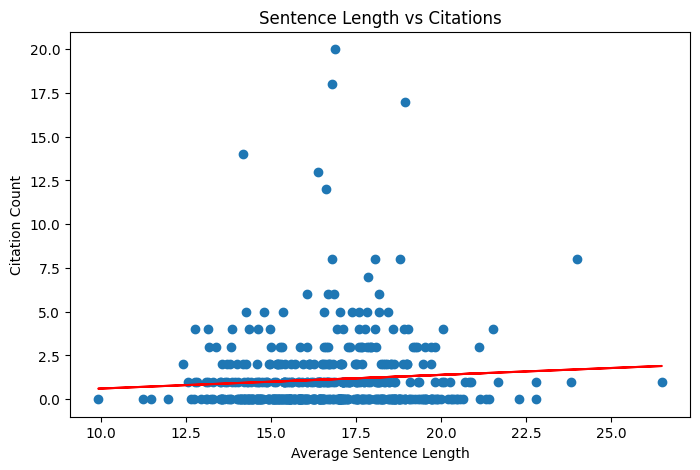

In [29]:
corr_sentence = df["avg_sentence_length"].corr(
    df["citation_count"]
)

print("Correlation:", corr_sentence)

plt.figure(figsize=(8,5))

plt.scatter(
    df["avg_sentence_length"],
    df["citation_count"]
)

import numpy as np

x = df["avg_sentence_length"]
y = df["citation_count"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(x, p(x), color="red")

plt.xlabel("Average Sentence Length")
plt.ylabel("Citation Count")
plt.title("Sentence Length vs Citations")

plt.show()

Strukturfeatures

0.003190278440663466


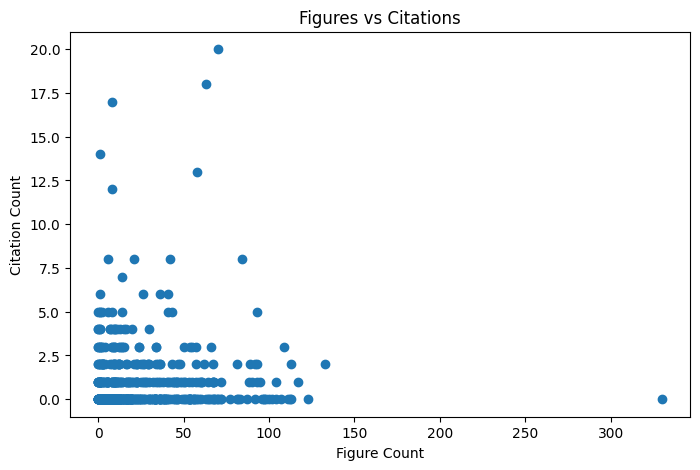

In [30]:
corr_figures = df["figure_count"].corr(
    df["citation_count"]
)

print(corr_figures)

plt.figure(figsize=(8,5))

plt.scatter(
    df["figure_count"],
    df["citation_count"]
)

plt.xlabel("Figure Count")
plt.ylabel("Citation Count")
plt.title("Figures vs Citations")

plt.show()

In [ ]:
# Zeile mit der höchsten Anzahl an Figures
# Manuelle Überprüfung zeigte, dass der Figure Count von 300+ valide ist da die pdf 100 Seiten beinhaltete mit exakt über 300 figgures 
max_fig_pdf = df.loc[df['figure_count'].idxmax()]

print(max_fig_pdf)

word_count                                                27903
sentence_count                                             1827
flesch_reading_ease                                   49.667055
gunning_fog                                           12.932304
flesch_kincaid_grade                                  10.092318
avg_sentence_length                                   15.137384
avg_letter_per_word                                    5.180756
lexicon_count                                             27656
figure_count                                                330
table_count                                                  11
section_count                                                 0
reference_count                                               0
doi                                   10.1101/2025.07.23.666348
file                              10.1101_2025.07.23.666348.pdf
citation_count                                                0
publication_year                        

Published vs Complexity

published_flag
1    14.645224
Name: gunning_fog, dtype: float64


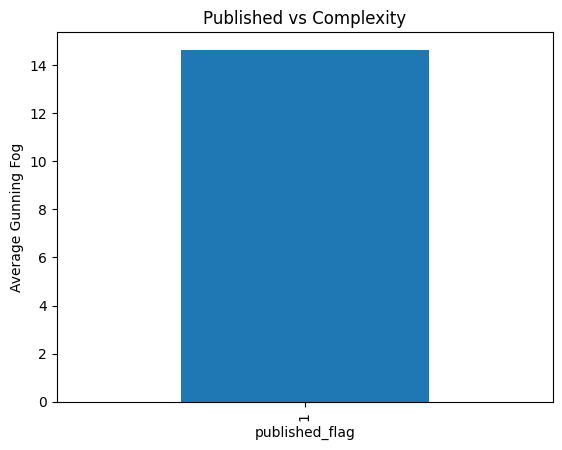

In [31]:
published_mean = df.groupby(
    "published_flag"
)["gunning_fog"].mean()

print(published_mean)

published_mean.plot(kind="bar")

plt.ylabel("Average Gunning Fog")

plt.title("Published vs Complexity")

plt.show()

Regression

In [32]:
X = df[[
    "gunning_fog",
    "avg_sentence_length",
    "figure_count"
]]

y = df["citation_count"]

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):

    print(feature, ":", coef)

Intercept: -0.005749515619851708
gunning_fog : -0.01933360224649312
avg_sentence_length : 0.08554842357133385
figure_count : -0.00022129188477649706


In [33]:
df[[
    "journal_name",
    "type",
    "published_flag"
]].head(20)

,journal_name,type,published_flag
0,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
1,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
2,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
3,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
4,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
5,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
6,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
7,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
8,bioRxiv (Cold Spring Harbor Laboratory),preprint,1
9,bioRxiv (Cold Spring Harbor Laboratory),preprint,1


In [34]:
df["type"].value_counts()

type
preprint    497
article       1
Name: count, dtype: int64

Full Dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "../output/full_dataset.csv",
    sep=";"
)

print(df.shape)

print(df.columns.tolist())

(7618, 24)
['word_count', 'sentence_count', 'flesch_reading_ease', 'gunning_fog', 'flesch_kincaid_grade', 'avg_sentence_length', 'avg_letter_per_word', 'lexicon_count', 'figure_count', 'table_count', 'section_count', 'reference_count', 'doi', 'preprint_date', 'preprint_category', 'published_doi', 'published_flag', 'citation_count', 'publication_year', 'citations_per_year', 'journal_name', 'is_open_access', 'type', 'openalex_id']


In [6]:
df["published_flag"].value_counts()
df.isnull().sum()


word_count                 0
sentence_count             0
flesch_reading_ease        0
gunning_fog                0
flesch_kincaid_grade       0
avg_sentence_length        0
avg_letter_per_word        0
lexicon_count              0
figure_count               0
table_count                0
section_count           7618
reference_count         7618
doi                        0
preprint_date              0
preprint_category          0
published_doi           7618
published_flag             0
citation_count            19
publication_year          19
citations_per_year      2043
journal_name              19
is_open_access            19
type                      19
openalex_id               19
dtype: int64

In [7]:
df.isnull().sum()

word_count                 0
sentence_count             0
flesch_reading_ease        0
gunning_fog                0
flesch_kincaid_grade       0
avg_sentence_length        0
avg_letter_per_word        0
lexicon_count              0
figure_count               0
table_count                0
section_count           7618
reference_count         7618
doi                        0
preprint_date              0
preprint_category          0
published_doi           7618
published_flag             0
citation_count            19
publication_year          19
citations_per_year      2043
journal_name              19
is_open_access            19
type                      19
openalex_id               19
dtype: int64

In [8]:
df[
    [
        "citation_count",
        "citations_per_year",
        "figure_count",
        "table_count",
        "section_count",
        "reference_count"
    ]
].describe()

,citation_count,citations_per_year,figure_count,table_count,section_count,reference_count
count,7599.000000,5575.000000,7618.000000,7618.000000,0.0,0.0
mean,4.402816,0.889247,8.137438,1.327120,NaN,NaN
std,9.176173,1.547932,5.257341,2.573861,NaN,NaN
min,0.000000,0.030000,0.000000,0.000000,NaN,NaN
25%,0.000000,0.250000,5.000000,0.000000,NaN,NaN
50%,2.000000,0.500000,7.000000,0.000000,NaN,NaN
75%,5.000000,1.000000,10.000000,2.000000,NaN,NaN
max,218.000000,54.500000,128.000000,85.000000,NaN,NaN


In [2]:
import pandas as pd

df = pd.read_csv(
    "../output/full_dataset.csv",
    sep=";"
)

df[
    [
        "section_count",
        "reference_count"
    ]
].describe()

,section_count,reference_count
count,7618.0,7618.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [3]:
df[
    [
        "section_count",
        "reference_count"
    ]
].isnull().sum()

section_count      0
reference_count    0
dtype: int64

In [4]:
df["published_flag"].value_counts()

published_flag
0    5239
1    2379
Name: count, dtype: int64

In [5]:
df["section_count"].value_counts().head()

df["reference_count"].value_counts().head()

reference_count
0    7618
Name: count, dtype: int64

In [6]:
df = pd.read_csv(
    "../output/full_dataset.csv",
    sep=";"
)

print(df.shape)

(7618, 24)


In [7]:
df["section_count"].value_counts().head()

df["reference_count"].value_counts().head()

reference_count
0    7618
Name: count, dtype: int64

In [9]:
import xml.etree.ElementTree as ET

xml_path = "../data/final_data/xml/10.1101_2019.12.09.869511_v1.xml"

tree = ET.parse(xml_path)

root = tree.getroot()

print(
    "Sections:",
    len(root.findall(".//sec"))
)

print(
    "References:",
    len(root.findall(".//ref"))
)

Sections: 15
References: 34


In [10]:
import os

json_files = os.listdir(
    "../data/final_data/json"
)

xml_files = os.listdir(
    "../data/final_data/xml"
)

print(json_files[0])
print(xml_files[0])

10.1101_004473_v2.json
10.1101_004473_v2.xml


In [14]:
df = pd.read_csv(
    "../output/full_dataset.csv",
    sep=";"
)

print(df.shape)

print(
    df[
        [
            "section_count",
            "reference_count"
        ]
    ].head()
)

EmptyDataError: No columns to parse from file

In [12]:
print(df["section_count"].unique()[:10])

print(df["reference_count"].unique()[:10])

[0]
[0]


In [18]:
import pandas as pd

df = pd.read_csv(
    "../output/full_dataset.csv",
    sep=";"
)

print(df.shape)

(7618, 17)


In [19]:
df[
    [
        "section_count",
        "reference_count"
    ]
].describe()

,section_count,reference_count
count,7617.000000,7617.000000
mean,25.215308,65.823159
std,10.820070,30.713672
min,1.000000,0.000000
25%,18.000000,46.000000
50%,24.000000,62.000000
75%,30.000000,80.000000
max,185.000000,580.000000


In [21]:
df["published_flag"].value_counts()

published_flag
0    7618
Name: count, dtype: int64

In [22]:
df["published_doi"].notna().sum()

np.int64(0)

In [23]:
df["published_doi"].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: published_doi, dtype: float64

In [24]:
import json

with open(
    "../data/final_data/json/10.1101_004473_v2.json",
    "r",
    encoding="utf-8"
) as f:

    data = json.load(f)

print(
    data["metadata"]["pub_metadata"].keys()
)

dict_keys(['preprint_doi', 'published_doi', 'published_journal', 'preprint_platform', 'preprint_title', 'preprint_authors', 'preprint_category', 'preprint_date', 'published_date', 'preprint_abstract', 'preprint_author_corresponding', 'preprint_author_corresponding_institution', 'local_pdf_path'])


In [25]:
import json

with open(
    "../data/final_data/json/10.1101_004473_v2.json",
    "r",
    encoding="utf-8"
) as f:

    data = json.load(f)

print(
    data["metadata"]["pub_metadata"]["published_doi"]
)

None


In [26]:
import requests

doi = "10.1101/2019.12.09.869511"

url = f"https://api.openalex.org/works/https://doi.org/{doi}"

response = requests.get(url)

print("Status Code:", response.status_code)

if response.status_code == 200:

    data = response.json()

    print("Citation Count:",
          data.get("cited_by_count"))

    print("Publication Year:",
          data.get("publication_year"))

    print("Type:",
          data.get("type"))

else:

    print(response.text[:500])

Status Code: 429
{"error":"Rate limit exceeded","message":"Insufficient budget. This request costs $0.0001 but you only have $0 remaining. Resets at midnight UTC. Need more? Add funds at https://openalex.org/pricing","retryAfter":34625,"costUsd":0.0001,"dailyRemainingUsd":0,"prepaidRemainingUsd":0,"creditsRequired":1,"creditsRemaining":0,"onetimeCreditsRemaining":0}
